In [1]:
import numpy as np
import hyperspy.api as hs

In [17]:
import matplotlib.pyplot as plt
import colorcet as cc
from matplotlib_scalebar.scalebar import ScaleBar

In [3]:
from skimage.feature import peak_local_max, match_template

In [8]:
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.ndimage import rotate

In [9]:
%matplotlib widget

In [7]:
dp_5K = hs.load(r"E:\EuAl4 Chiral\Good Data\SAED\Temp Dependence\5K.dm4")
dp_100K = hs.load(r"E:\EuAl4 Chiral\Good Data\SAED\Temp Dependence\100K.dm4")

In [12]:
dp_5K.axes_manager

Signal axis name,size,,offset,scale,units
x,4096,,-0.0,0.013114077039062977,1/nm
y,4096,,-0.0,0.013114077039062977,1/nm


In [13]:
dp_100K.axes_manager

Signal axis name,size,,offset,scale,units
x,4096,,-0.0,0.013114077039062977,1/nm
y,4096,,-0.0,0.013114077039062977,1/nm


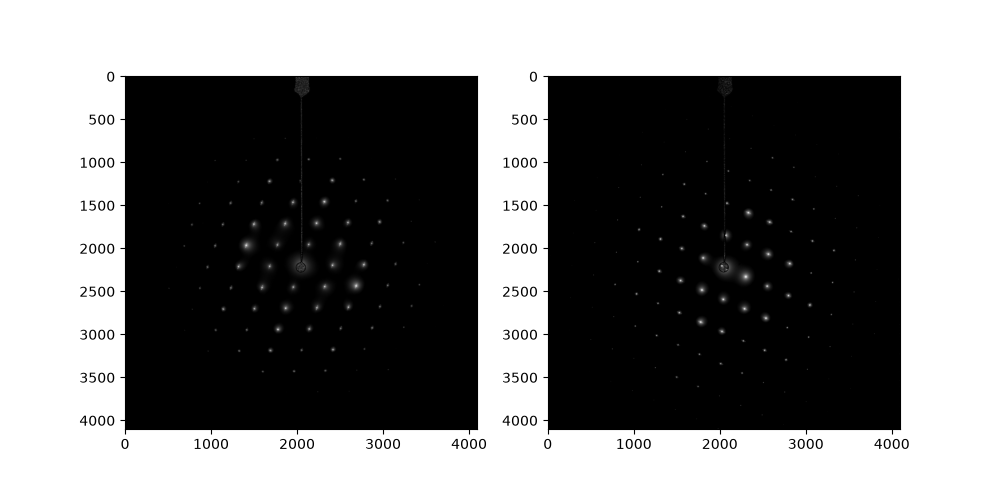

In [11]:
_, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(dp_5K.data, cmap='gray', norm = 'log', vmin = 3e4)
axs[1].imshow(dp_100K.data, cmap='gray', norm = 'log', vmin = 3e4)

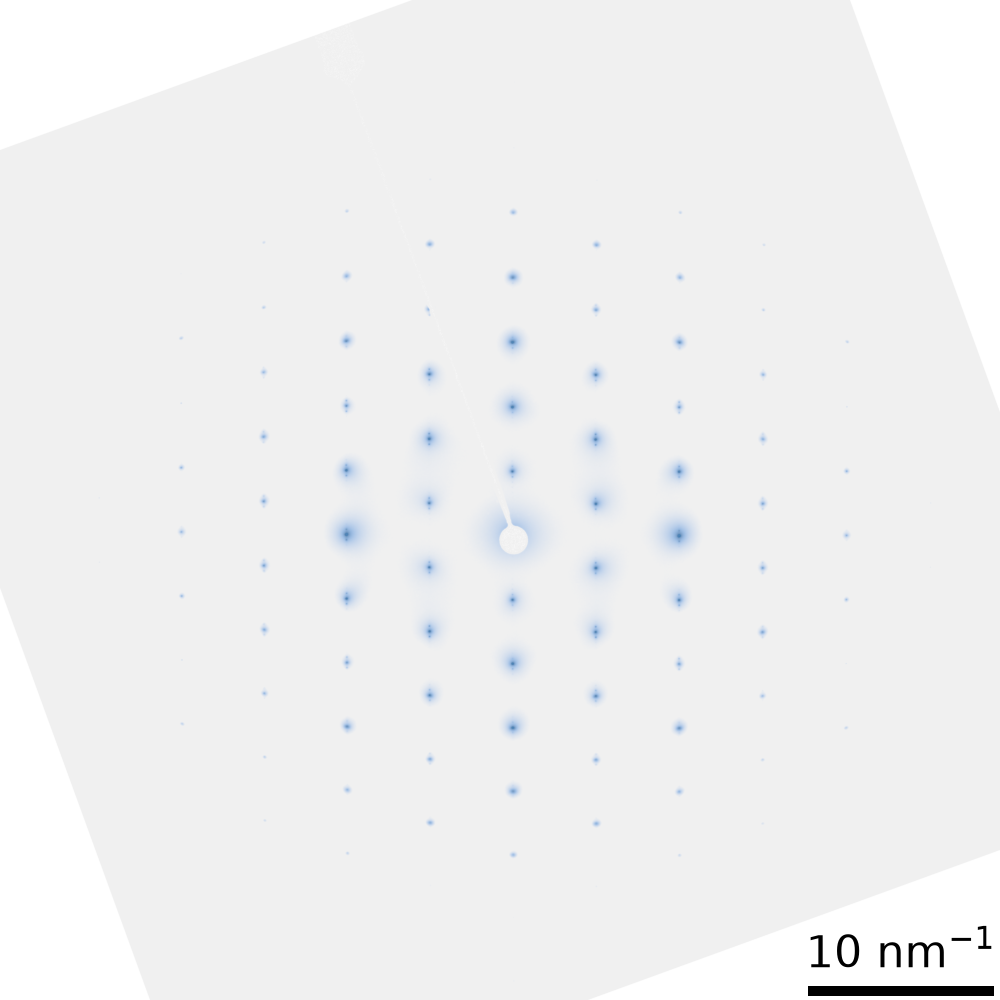

In [30]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0, 0, 1, 1)
ax = plt.gca()
ax.imshow(rotate(dp_5K.data, 20, reshape = False), cmap="cet_blues", norm = 'log', vmin = 3e4)
sbar = ScaleBar(
    0.013114077039062977,
    units = "1/nm",
    dimension = "si-length-reciprocal",
    location = "lower right",
    scale_loc = "top",
    frameon=False,
    color = "k",
    font_properties = {"size": 32},
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(r"E:\EuAl4 Chiral\Good Data\SAED\Temp Dependence\5K.svg", dpi = 300, bbox_inches = "tight", pad_inches = 0)

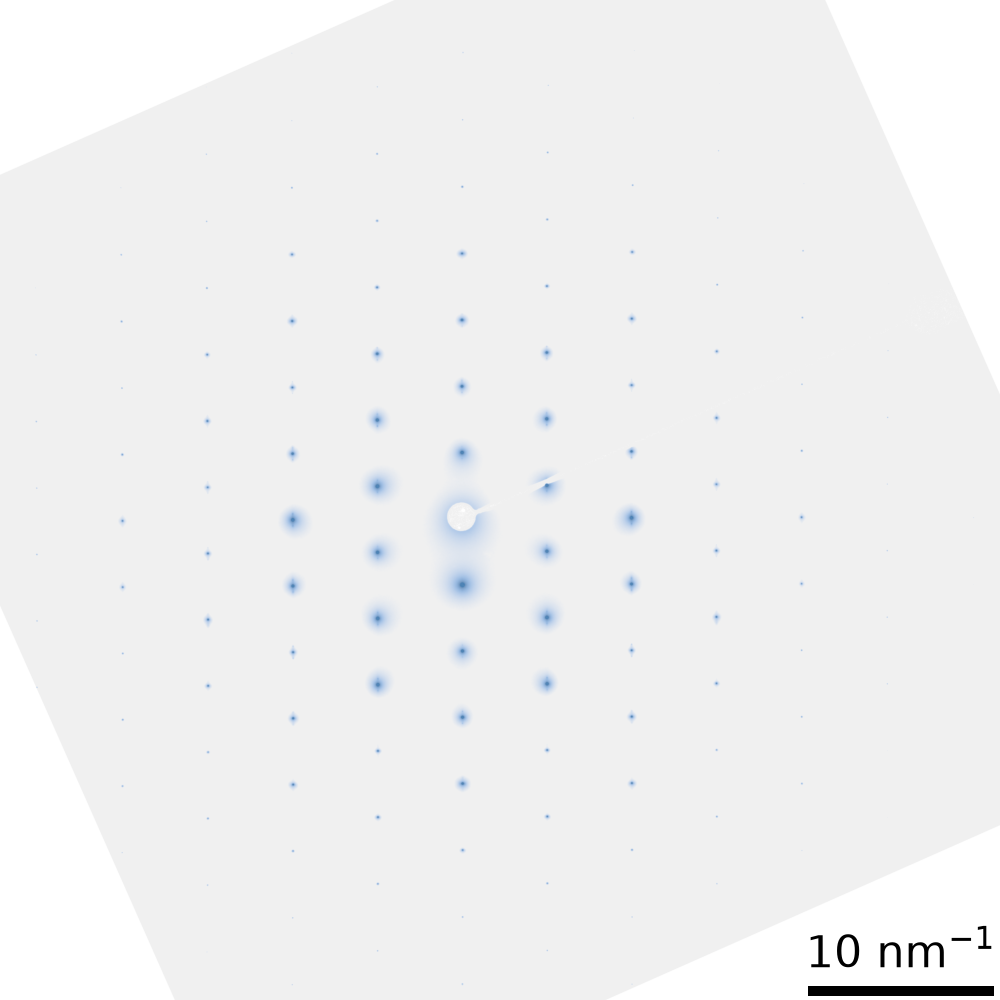

In [31]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0, 0, 1, 1)
ax = plt.gca()
ax.imshow(rotate(dp_100K.data, -66.1, reshape = False), cmap="cet_blues", norm = 'log', vmin = 3e4)
sbar = ScaleBar(
    0.013114077039062977,
    units = "1/nm",
    dimension = "si-length-reciprocal",
    location = "lower right",
    scale_loc = "top",
    frameon=False,
    color = "k",
    font_properties = {"size": 32},
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(r"E:\EuAl4 Chiral\Good Data\SAED\Temp Dependence\100K.svg", dpi = 300, bbox_inches = "tight", pad_inches = 0)

In [60]:
lp_5K = rotate(dp_5K.data, 20, reshape = False)[2194-100:2194+100, 2780-5:2780+5].sum(1)
lp_100K = rotate(dp_100K.data, -66.1, reshape = False)[2121-100:2121+100, 2586-5:2586+5].sum(1)

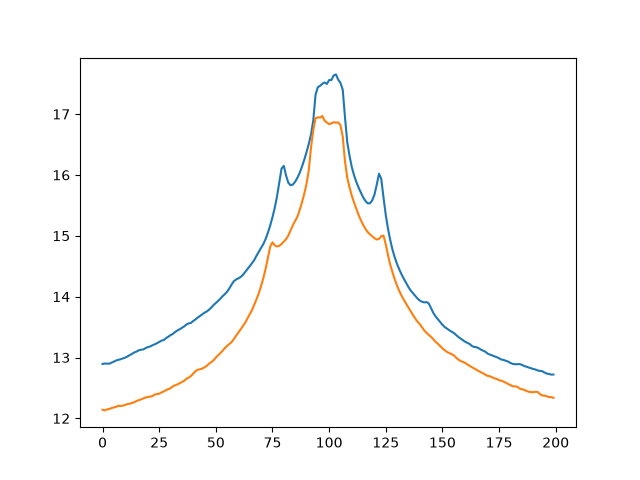

In [ ]:
plt.figure()
plt.plot(np.log(lp_5K))
plt.plot(np.log(lp_100K))n